In [27]:
import pandas as pd

df = pd.read_csv('dynamic_supply_chain_logistics_dataset.csv')
df

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,...,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,...,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,...,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,...,-6.951137,0.407377,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956879


In [28]:
# converting the time stamp feature to date time format: 

import datetime as dt

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df['timestamp'].dt.month
df['hour'] = df['timestamp'].dt.hour

df['time_of_day'] = pd.cut(
    df['hour'], 
    bins=[-1, 6, 12, 18, 24], 
    labels=['night', 'morning', 'afternoon', 'evening']
)

In [29]:
df
cols_to_drop = [
    'timestamp',               # Redundant (already extracted)
    'time_of_day',             # Redundant (less precise than hour)
    'risk_classification',     # Redundant (label for probability)
    'order_fulfillment_status', # Target leakage
    'delivery_time_deviation'  # Target leakage
]

df = df.drop(columns=cols_to_drop)
df

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,weather_condition_severity,port_congestion_level,...,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,day_of_week,is_weekend,month,hour
0,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.359066,4.289160,...,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,4,0,1,0
1,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.230660,7.018373,...,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,4,0,1,1
2,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.027210,9.605064,...,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,4,0,1,2
3,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.616619,8.899616,...,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,4,0,1,3
4,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.952385,0.061760,...,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,4,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.792648,9.700832,...,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,2,0,8,20
32061,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.034156,2.752909,...,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,2,0,8,21
32062,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.022338,0.498235,...,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,2,0,8,22
32063,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.782338,9.697467,...,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,2,0,8,23


In [33]:
cat_features = ['day_of_week', 'month', 'hour', 'is_weekend']
for col in cat_features: 
    df[col] = df[col].astype('category')

In [40]:
from sklearn.model_selection import train_test_split
 
X = df.drop('delay_probability', axis=1)
y = df['delay_probability'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from lightgbm import LGBMRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
import numpy as np 
lgbm = LGBMRegressor()

params = {
    'n_estimators': [500, 1000, 1500, 2000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2] , 
    'num_leaves': np.arange(10, 100, 10), 
    'min_child_samples': [20, 50, 100]
}

In [45]:
# testing without hyperparameters first 
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5404
[LightGBM] [Info] Number of data points in the train set: 25652, number of used features: 25
[LightGBM] [Info] Start training from score 0.698090


In [46]:
 
print(lgbm.score(X_train, y_train))
 
print(lgbm.score(X_test, y_test))

0.18552133455954278
-0.015846479660953428


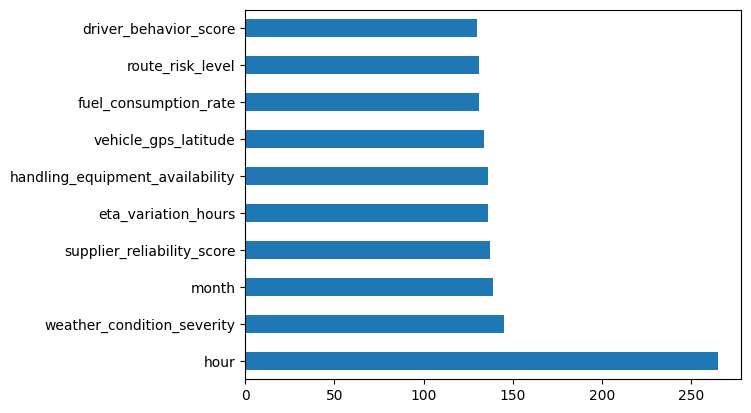

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# See what the model actually cares about
feat_imp = pd.Series(lgbm.feature_importances_, index=X_train.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.show()

In [47]:
# Check if your features actually correlate with the target
correlations = df.corr()['delay_probability'].sort_values(ascending=False)
print(correlations.head(10))

delay_probability                  1.000000
port_congestion_level              0.008972
hour                               0.007641
customs_clearance_time             0.004896
warehouse_inventory_level          0.004686
cargo_condition_status             0.002910
handling_equipment_availability    0.002690
supplier_reliability_score         0.001890
weather_condition_severity         0.001503
lead_time_days                     0.001083
Name: delay_probability, dtype: float64
